# genoselect — a visual walkthrough

Genomic prediction in Python, explained with pictures. Runs on a simulated population with **three subpopulations**. Run the cells top to bottom (**Run All**).

## 1. A structured dummy population

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
import genoselect as gs

rng = np.random.default_rng(1)
plt.rcParams["figure.figsize"] = (7, 4.2)
pal = {"Pop1": "#2c7fb8", "Pop2": "#d95f02", "Pop3": "#1b9e77"}

n_per, n_pop, m = 60, 3, 500
pops = np.repeat([f"Pop{k+1}" for k in range(n_pop)], n_per)
n = n_per * n_pop

base_p = rng.uniform(0.1, 0.9, size=m)
geno = np.zeros((n, m))
for k in range(n_pop):                       # per-population allele-freq shift
    pk = np.clip(base_p + rng.normal(0, 0.08, size=m) * (k - 1), 0.02, 0.98)
    geno[k*n_per:(k+1)*n_per] = rng.binomial(2, pk, size=(n_per, m))

qtl = rng.choice(m, size=40, replace=False)
gv = (geno[:, qtl] - 2 * base_p[qtl]) @ rng.normal(size=40)
gv = gv / gv.std()
pheno = gv + rng.normal(scale=np.sqrt((1 - 0.5) / 0.5), size=n)
print(f"{n} individuals x {m} markers; {n_pop} subpopulations")

180 individuals x 500 markers; 3 subpopulations


## 2. The trait

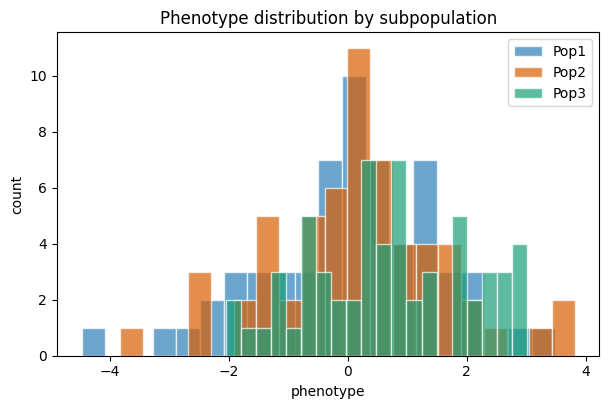

In [2]:
fig, ax = plt.subplots()
for pop, col in pal.items():
    ax.hist(pheno[pops == pop], bins=20, alpha=0.7, label=pop, color=col, edgecolor="white")
ax.set(title="Phenotype distribution by subpopulation", xlabel="phenotype", ylabel="count")
ax.legend(); plt.show()

## 3. Allele-frequency spectrum

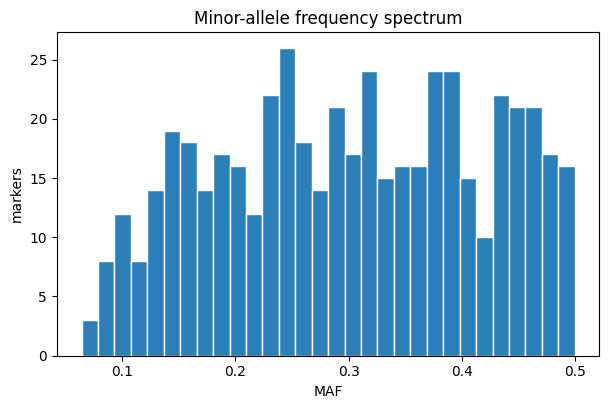

In [3]:
p = geno.mean(0) / 2
plt.hist(np.minimum(p, 1 - p), bins=30, color="#2c7fb8", edgecolor="white")
plt.title("Minor-allele frequency spectrum"); plt.xlabel("MAF"); plt.ylabel("markers"); plt.show()

## 4. Genomic relationship matrix

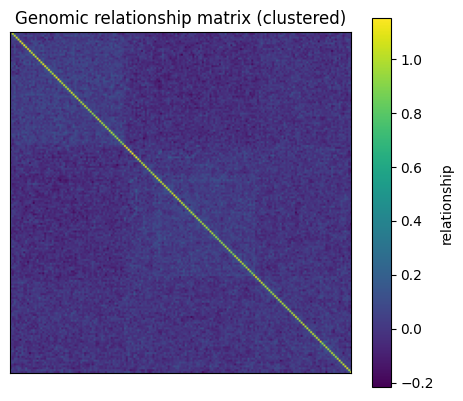

In [4]:
G = gs.vanraden_grm(geno)
order = leaves_list(linkage(G, method="average"))
Go = G[np.ix_(order, order)]
fig, ax = plt.subplots(figsize=(5.5, 4.8))
im = ax.imshow(Go, cmap="viridis")
ax.set(title="Genomic relationship matrix (clustered)", xticks=[], yticks=[])
fig.colorbar(im, label="relationship"); plt.show()

## 5. Population structure (PCA)

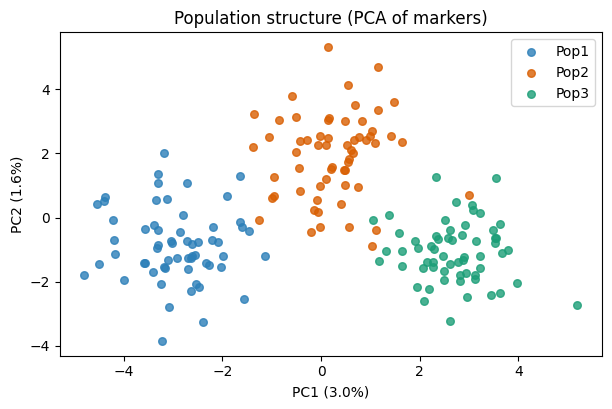

In [5]:
Xc = geno - geno.mean(0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
scores = U * S
ve = S**2 / np.sum(S**2)
fig, ax = plt.subplots()
for pop, col in pal.items():
    sel = pops == pop
    ax.scatter(scores[sel, 0], scores[sel, 1], s=30, alpha=0.8, color=col, label=pop)
ax.set(title="Population structure (PCA of markers)",
       xlabel=f"PC1 ({100*ve[0]:.1f}%)", ylabel=f"PC2 ({100*ve[1]:.1f}%)")
ax.legend(); plt.show()

## 6. Clustering dendrogram

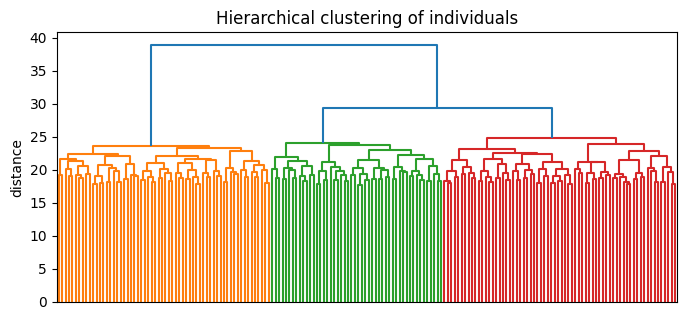

In [6]:
Z = linkage(geno, method="ward")
fig, ax = plt.subplots(figsize=(8, 3.5))
dendrogram(Z, no_labels=True, color_threshold=Z[-2, 2], ax=ax)
ax.set(title="Hierarchical clustering of individuals", ylabel="distance"); plt.show()

## 7. GBLUP: heritability and variance components

estimated genomic h2 = 0.317


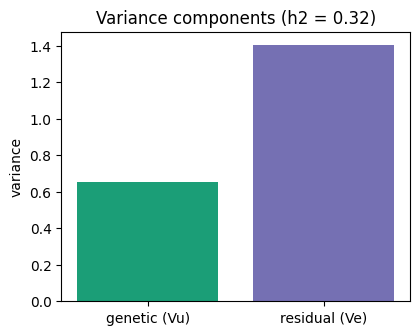

In [7]:
test = rng.choice(n, size=45, replace=False)
train = np.setdiff1d(np.arange(n), test)
fit = gs.GBLUP().fit(geno[train], pheno[train])
print(f"estimated genomic h2 = {fit.h2_:.3f}")
fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.bar(["genetic (Vu)", "residual (Ve)"], [fit.Vu_, fit.Ve_], color=["#1b9e77", "#7570b3"])
ax.set(title=f"Variance components (h2 = {fit.h2_:.2f})", ylabel="variance"); plt.show()

## 8. Predicted vs observed (test set)

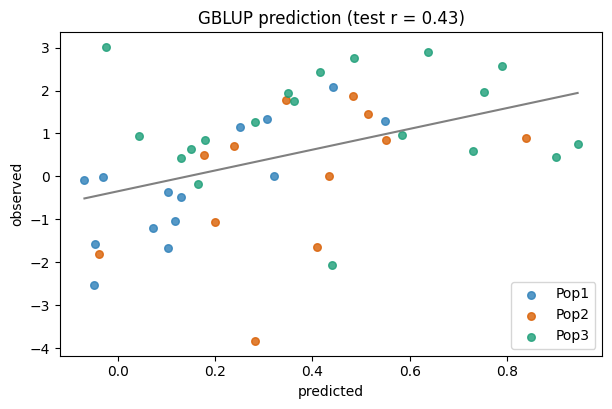

In [8]:
pred = fit.predict(geno[test])
r = np.corrcoef(pred, pheno[test])[0, 1]
fig, ax = plt.subplots()
for pop, col in pal.items():
    sel = pops[test] == pop
    ax.scatter(pred[sel], pheno[test][sel], s=30, alpha=0.8, color=col, label=pop)
b, a = np.polyfit(pred, pheno[test], 1)
xs = np.array([pred.min(), pred.max()]); ax.plot(xs, a + b * xs, color="grey")
ax.set(title=f"GBLUP prediction (test r = {r:.2f})", xlabel="predicted", ylabel="observed")
ax.legend(); plt.show()

## 9. Where the signal is: marker effects

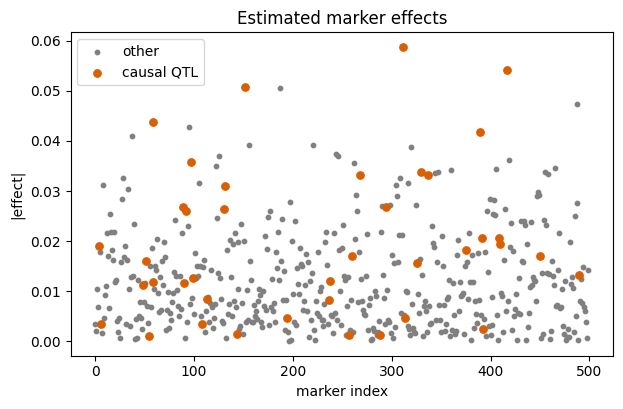

In [9]:
eff = np.abs(fit.marker_effects_)
idx = np.arange(eff.size)
causal = np.isin(idx, qtl)
fig, ax = plt.subplots()
ax.scatter(idx[~causal], eff[~causal], s=10, color="grey", label="other")
ax.scatter(idx[causal], eff[causal], s=28, color="#d95f02", label="causal QTL")
ax.set(title="Estimated marker effects", xlabel="marker index", ylabel="|effect|")
ax.legend(); plt.show()

## 10. Breeding values by subpopulation

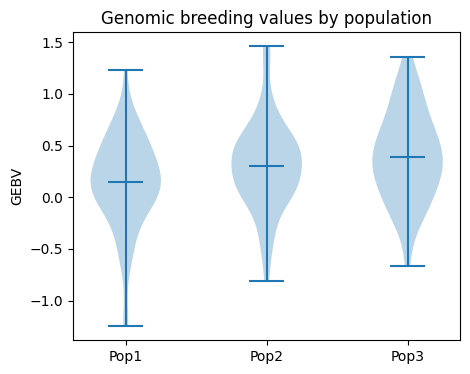

In [10]:
gebv = fit.predict(geno)
data = [gebv[pops == pop] for pop in pal]
fig, ax = plt.subplots(figsize=(5, 4))
ax.violinplot(data, showmeans=True)
ax.set_xticks([1, 2, 3]); ax.set_xticklabels(list(pal))
ax.set(title="Genomic breeding values by population", ylabel="GEBV"); plt.show()

## 11. Model comparison by cross-validation

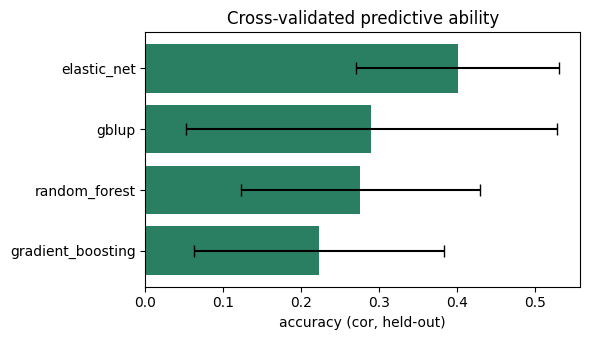

,model,mean,sd,n_folds
0,elastic_net,0.400331,0.130390,5
1,gblup,0.289594,0.237730,5
2,random_forest,0.275569,0.153253,5
3,gradient_boosting,0.222700,0.159941,5


In [11]:
cv = gs.cross_validate(geno, pheno,
        models=["gblup", "elastic_net", "random_forest", "gradient_boosting"],
        k=5, random_state=1)
s = cv.summary().sort_values("mean")
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(s["model"], s["mean"], xerr=s["sd"], color="#2a7f62", capsize=4)
ax.set(title="Cross-validated predictive ability", xlabel="accuracy (cor, held-out)")
plt.tight_layout(); plt.show()
cv.summary()

## 12. Stacked super-learner ensemble

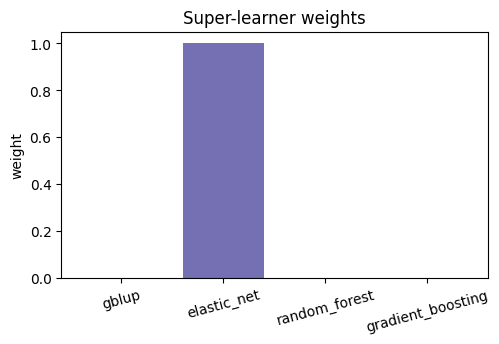

ensemble test accuracy: 0.239


In [12]:
ens = gs.StackedEnsemble(random_state=1).fit(geno[train], pheno[train])
w = ens.weights_
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.bar(list(w), list(w.values()), color="#7570b3")
ax.set(title="Super-learner weights", ylabel="weight"); plt.xticks(rotation=15); plt.show()
pe = ens.predict(geno[test])
print(f"ensemble test accuracy: {np.corrcoef(pe, pheno[test])[0,1]:.3f}")

# Summary

You have visualised the full genoselect workflow: data + structure, the GRM, PCA and clustering, GBLUP variance components and predictions, the causal signal, breeding values by group, and an honest model comparison. See the [documentation](https://mqfarooqi1.github.io/genoselect/).